In [157]:
# suggested values
alpha_val = 0.9
beta_val = 0.2
small_gamma_val = 0.1
lambda_0 = 1
lambda_1 = 5

n = 10
big_T = 100

# implemeting the transition matrix gamma 

In [158]:
import numpy as np

#column 0 = serial 0
#column 1 = serial 1
#column 2 = parallel

def create_transition_matrix(gamma, beta):
    Gamma = np.array([
            [(1-gamma)  ,0          ,gamma],
            [0          ,(1-gamma)  ,gamma],
            [(beta/2)   ,(beta/2)   ,(1-beta)]
            ], dtype=float)
    return Gamma

In [159]:
test_matrix = create_transition_matrix(small_gamma_val, beta_val)
print(test_matrix)
test_matrix[2]

[[0.9 0.  0.1]
 [0.  0.9 0.1]
 [0.1 0.1 0.8]]


array([0.1, 0.1, 0.8])

# implemeting the conditional probability for Z_{t,i}

In [160]:
def p_z1_given_c(alpha, c):
    if c == 0:
        return (1-alpha)
    elif c == 1:
        return alpha 
    elif c == 2:
        return (0.5)
    else:
        raise ValueError("c must be 0, 1 or 2")

# simulation

In [161]:
def simulate_c(T, gamma, beta, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    Gamma = create_transition_matrix(gamma, beta)
    #print(Gamma)

    C = np.empty(T, dtype=int)
    C[0] =  2  #P(C_1=2)=1, just the first state

    states = np.array([0, 1, 2], dtype=int)

    for t in range(1, T):
        C[t] = rng.choice(states, p=Gamma[C[t-1]])

    return C

In [162]:
#sim_c = simulate_c(big_T, small_gamma_val, beta_val)
#sim_c

## simulate Z from C

In [163]:
def simulate_z(C, n, alpha, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    T = len(C)

    Z = np.empty((T, n), dtype=int)

    for t in range(T):
        p = p_z1_given_c(alpha, C[t])
        Z[t] = rng.binomial(n=1, p=p, size=n)

    return Z

In [164]:
#sim_z = simulate_z(sim_c, n, alpha_val)
#sim_z

## simulate X from Z

In [165]:
def simulate_x(Z, lambda_0, lambda_1, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    lam = lambda_0 + (lambda_1 - lambda_0) * Z
    X = rng.poisson(lam=lam)
    return X

In [166]:
#sim_x = simulate_x(sim_z, lambda_0, lambda_1)
#sim_x

# Full simulation of HMM

In [167]:
def simulate_hmm(T, n, alpha, beta, gamma, lambda_0, lambda_1, seed=None):
    rng = np.random.default_rng(seed)

    c = simulate_c(T=T, gamma=gamma, beta=beta, rng=rng)
    z = simulate_z(C=c, n=n, alpha=alpha, rng=rng)
    x = simulate_x(Z=z, lambda_0=lambda_0, lambda_1=lambda_1, rng=rng)

    return c, z, x 

In [168]:
C, Z, X = simulate_hmm(big_T, n, alpha_val, beta_val, small_gamma_val, lambda_0, lambda_1)

In [169]:
print(C.shape)
print(Z.shape)
print(X.shape)

(100,)
(100, 10)
(100, 10)


# Plotting

In [170]:
import matplotlib.pyplot as plt

In [171]:
def plot_single(X):
    t_vals = np.arange(1, X.shape[0]+1)

    plt.figure(figsize=(12,4))
    plt.plot(t_vals, X[:, 0], marker="o", markersize=4)
    plt.xlabel("t")
    plt.ylabel(r"$X_{t,1}$")
    plt.grid(alpha=0.6)
    plt.title("spikes count over time for neuron 1")
    plt.show()

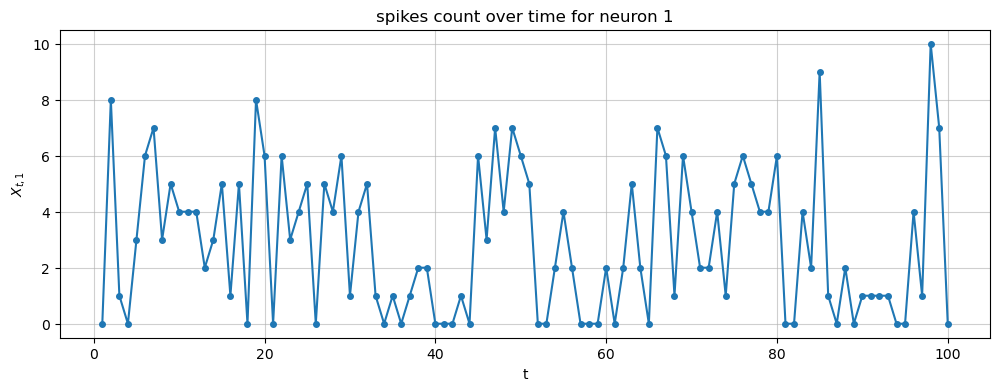

In [172]:
plot_single(X)

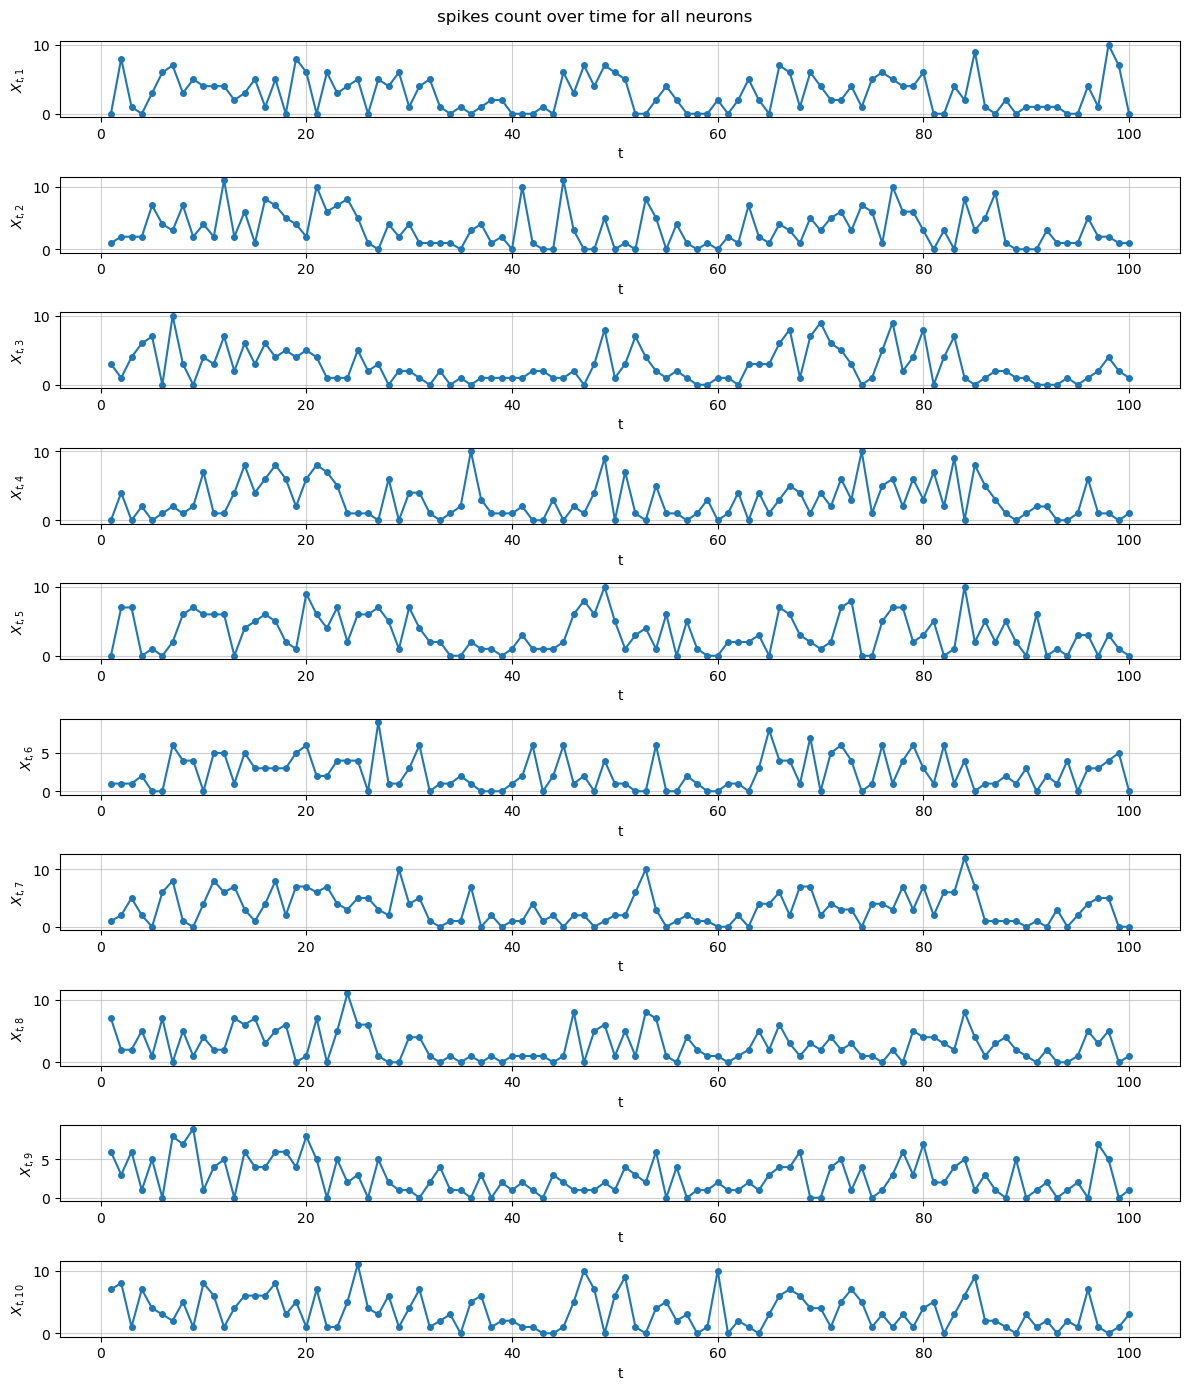

In [173]:
def plot_all(X):
    t_vals = np.arange(1, X.shape[0]+1)
    n = X.shape[1]
    fig, axes = plt.subplots(n, 1, figsize=(12, 1.4*n))
    for i in range(n):
        axes[i].plot(t_vals, X[:, i], marker="o", markersize=4)
        axes[i].set_xlabel("t")
        axes[i].set_ylabel(rf"$X_{{t,{i+1}}}$")
        axes[i].grid(alpha=0.6)
    plt.suptitle("spikes count over time for all neurons", y=0.99)
    plt.tight_layout()
    plt.show()

plot_all(X)

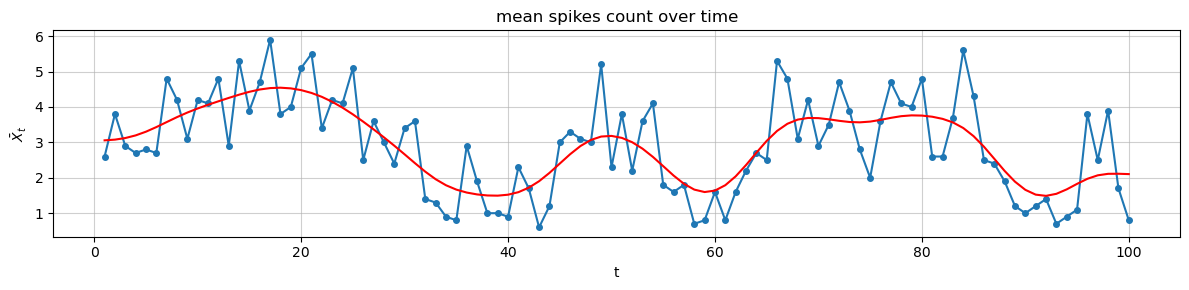

In [174]:
from scipy.ndimage import gaussian_filter1d

def plot_mean(X):
    t_vals = np.arange(1, X.shape[0] + 1)
    mean_X = X.mean(axis=1)
    smooth_mean = gaussian_filter1d(mean_X, sigma=3)

    plt.figure(figsize=(12, 3))
    plt.plot(t_vals, mean_X, marker="o", markersize=4)
    plt.plot(t_vals, smooth_mean, color="r")
    plt.xlabel("t")
    plt.ylabel(r"$\bar{X}_t$")
    plt.grid(alpha=0.6)
    plt.title("mean spikes count over time")
    plt.tight_layout()
    plt.show()

plot_mean(X)